<a href="https://colab.research.google.com/github/gkmfrombs/isro-land-use-classifier/blob/main/01_EDA_and_Data_Loading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Loading the data**
**Land Cover Classification : Bhuvan Satellite Data**



--------------------------------------------------------------------
--------------------------------------------------------------------

# 🛰️ ISRO Bhuvan Land Cover Classification (Varanasi)

### Dataset Overview
This notebook uses high-resolution 2D satellite imagery of Varanasi, India, sourced from the Indian Space Research Organisation (ISRO). It is pre-processed for pixel-level image segmentation tasks.

**The 5 Target Classes:**
* Vegetation
* Urban Areas
* Forest
* Water Bodies
* Roads

**Data Structure:**
* `train_image` & `test_image`: The raw satellite photos fed into the neural network.
* `train_mask` & `test_mask`: The labeled images where every pixel is color-coded to a target class.
* `class_dict_seg.csv`: Maps the exact RGB colors in the masks to their actual class names.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khushiipatni/satellite-image-and-mask")

print("Path to dataset files:", path)

100%|██████████| 7.39M/7.39M [00:00<00:00, 72.8MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/khushiipatni/satellite-image-and-mask/versions/4


The dataset has been successfully downloaded to the following path: `/root/.cache/kagglehub/datasets/khushiipatni/satellite-image-and-mask/versions/4`

##**EDA**

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [3]:
dataset_path = '/root/.cache/kagglehub/datasets/khushiipatni/satellite-image-and-mask/versions/4'
image_dir = os.path.join(dataset_path, 'train_image')
mask_dir = os.path.join(dataset_path, 'train_mask')

In [4]:
# Get the filename of the very first image in the training folder
first_image_name = os.listdir(image_dir)[0]
first_image_name

'PHOTO-2023-04-08-11-40-40.jpg'

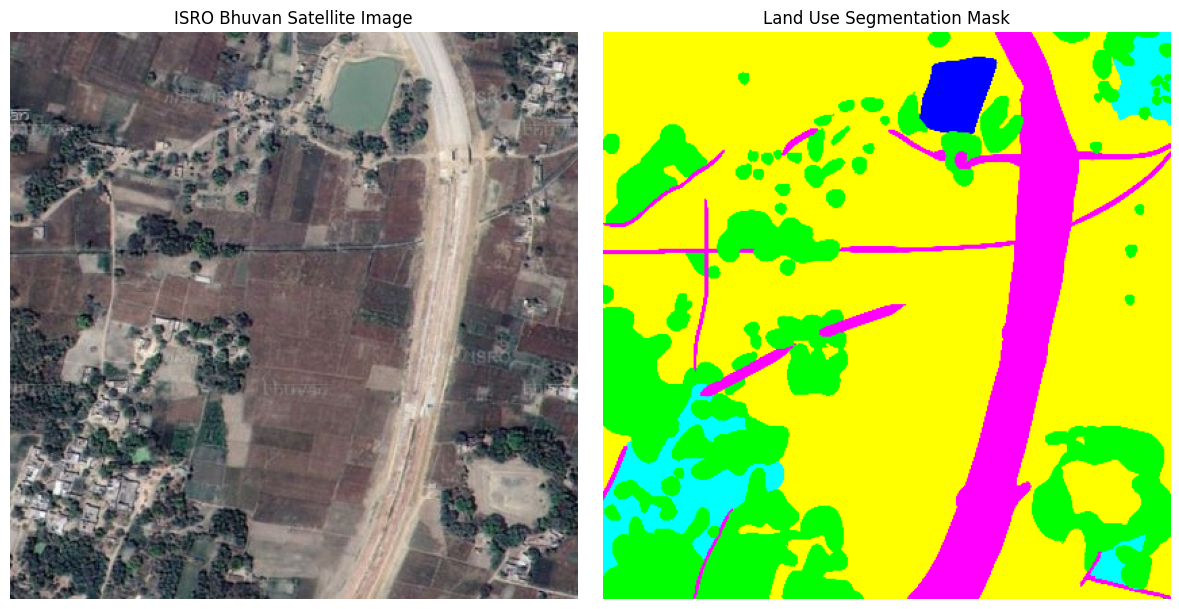

Image Shape (Height, Width, Channels): (420, 420, 3)
Mask Shape (Height, Width, Channels): (420, 420, 3)


In [6]:
# Load the image and its corresponding mask
img_path = os.path.join(image_dir, first_image_name)
mask_path = os.path.join(mask_dir, first_image_name) # Initial assumption for mask path

# OpenCV loads images in BGR format, so we convert them to RGB so the colors look right
img = cv2.imread(img_path)
if img is None:
    print(f"Error: Could not load image from path: {img_path}")
    # Exit to prevent further errors if the primary image isn't loaded
    raise FileNotFoundError(f"Image file not found or corrupted: {img_path}")

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Try loading the mask with the same name first
mask = cv2.imread(mask_path)

# If mask is None, try common alternative extensions like .png
if mask is None:
    base_name, _ = os.path.splitext(first_image_name)
    potential_mask_path_png = os.path.join(mask_dir, base_name + '.png')
    mask = cv2.imread(potential_mask_path_png)
    if mask is not None:
        mask_path = potential_mask_path_png # Update mask_path if .png was found
    else:
        print(f"Error: Could not load mask image from path: {mask_path}")
        print(f"Also tried: {potential_mask_path_png}")
        # Exit to prevent further errors if the mask isn't loaded
        raise FileNotFoundError(f"Mask file not found or corrupted. Tried: {mask_path}, {potential_mask_path_png}")

mask = cv2.cvtColor(mask, cv2.COLOR_BGR2RGB)

# Plot them side-by-side
fig, arr = plt.subplots(1, 2, figsize=(12, 6))
arr[0].imshow(img)
arr[0].set_title('ISRO Bhuvan Satellite Image')
arr[0].axis('off')

arr[1].imshow(mask)
arr[1].set_title('Land Use Segmentation Mask')
arr[1].axis('off')

plt.tight_layout()
plt.show()

# Print the shape to understand the dimensions for the neural network
print(f"Image Shape (Height, Width, Channels): {img.shape}")
print(f"Mask Shape (Height, Width, Channels): {mask.shape}")


In [7]:
# Load the class dictionary CSV
csv_path = os.path.join(dataset_path, 'class_dict_seg.csv')
class_df = pd.read_csv(csv_path)

print("Color Mapping for Land Use Classes:")
display(class_df)

Color Mapping for Land Use Classes:


,name,r,g,b
0,urban,0,255,255
1,water,0,0,255
2,forest,0,255,0
3,argiculture,255,255,0
4,road,255,0,255


In [8]:
import numpy as np
import cv2

# Target size for the model
IMG_SIZE = 256

# Exact mapping from your CSV output
# Format: { 'class_name': (Class_ID, [R, G, B]) }
class_mapping = {
    'urban': (0, [0, 255, 255]),
    'water': (1, [0, 0, 255]),
    'forest': (2, [0, 255, 0]),
    'argiculture': (3, [255, 255, 0]),
    'road': (4, [255, 0, 255])
}

def preprocess_mask(mask_image):
    # 1. Resize the mask to 256x256 (using NEAREST to prevent blending colors)
    resized = cv2.resize(mask_image, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_NEAREST)

    # 2. Create an empty 256x256 array filled with zeros (single channel)
    label_mask = np.zeros((IMG_SIZE, IMG_SIZE), dtype=np.uint8)

    # 3. Swap the RGB colors for the Class IDs (0, 1, 2, 3, 4)
    for class_info in class_mapping.values():
        class_id = class_info[0]
        color = class_info[1]

        # Find all pixels matching this exact color
        matches = np.all(resized == color, axis=-1)
        label_mask[matches] = class_id

    # Add the final '1' channel dimension so it becomes (256, 256, 1)
    return np.expand_dims(label_mask, axis=-1)

# Test it on the mask we loaded earlier!
processed_mask = preprocess_mask(mask)

print(f"Old mask shape: {mask.shape}")
print(f"New processed mask shape: {processed_mask.shape}")
print(f"Unique class numbers in this image: {np.unique(processed_mask)}")

Old mask shape: (420, 420, 3)
New processed mask shape: (256, 256, 1)
Unique class numbers in this image: [0 1 2 3 4]


-------------------------------------------------------------------------

### Explanation

**Situation:** The project aims to perform land cover classification on high-resolution satellite imagery from ISRO Bhuvan, specifically for Varanasi, India.

**Task:** The objective is to identify and segment five distinct land cover classes (Vegetation, Urban Areas, Forest, Water Bodies, Roads) at a pixel level from the raw satellite images.

**Action:**
1. The necessary dataset, containing satellite images and their corresponding pixel-level masks, was downloaded from Kaggle.
2. Key libraries like `os`, `cv2`, `matplotlib`, `numpy`, and `pandas` were imported for data handling and visualization.
3. A sample image and its mask were loaded, visualized, and their dimensions inspected.
4. A `class_dict_seg.csv` file was used to establish the RGB-to-class mapping for the segmentation masks.
5. A `preprocess_mask` function was implemented to resize the masks and convert the RGB color-coded pixels into numerical class IDs (0-4), preparing them for model input.

**Result:**
- The satellite image dataset was successfully acquired and its structure understood.
- A robust method for loading and displaying image-mask pairs was established.
- A crucial mask preprocessing step was developed and verified, successfully converting visual masks into numerical labels essential for training a segmentation model.